# FinNexus — XGBoost Training Notebook

Trains one XGBoost classifier **per asset** across all asset classes.

**Data:** `Train/<AssetClass>/<SYMBOL>_features.csv`  
**Target:** `target_7d` (binary: 1=up, 0=down/flat) — configurable  
**Output:**
- `Data/XGBoost_Results/models/<AssetClass>/<SYMBOL>_xgb.pkl`
- `Data/XGBoost_Results/training_summary.csv`
- `Data/XGBoost_Results/feature_importance/`
- `Data/XGBoost_Results/xgb_training_report.txt`


## 1. Setup & Configuration

In [8]:
import os, sys, warnings, logging, pickle, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm as tqdm

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
logging.basicConfig(level=logging.INFO, format='%(message)s')
log = logging.getLogger('xg_train')

print(f'XGBoost : {xgb.__version__}  |  NumPy : {np.__version__}  |  Pandas : {pd.__version__}')

XGBoost : 3.2.0  |  NumPy : 2.2.6  |  Pandas : 2.2.3


In [9]:
ROOT       = Path('..').resolve()
TRAIN_DIR  = ROOT / 'Train'
OUTPUT_DIR = ROOT / 'Data' / 'XGBoost_Results'
MODEL_DIR  = OUTPUT_DIR / 'models'
FEAT_DIR   = OUTPUT_DIR / 'feature_importance'

for d in [OUTPUT_DIR, MODEL_DIR, FEAT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET_COL   = 'target_7d'
N_CV_SPLITS  = 5
RANDOM_STATE = 42
N_JOBS       = -1

DROP_COLS = [
    'Date', 'Open', 'High', 'Low', 'Close', 'Volume',
    'is_outlier', 'data_quality',
    'target_3d', 'target_5d', 'target_7d', 'target_10d', 'target_14d'
]

ASSET_CLASSES = ['Crypto', 'ETFs', 'Commodities', 'Futures', 'Stocks']

XGB_PARAMS = {
    'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3,
    'gamma': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'scale_pos_weight': 1, 'eval_metric': 'logloss',
    'random_state': RANDOM_STATE, 'n_jobs': N_JOBS, 'verbosity': 0,
}

print(f'ROOT       : {ROOT}')
print(f'TRAIN_DIR  : {TRAIN_DIR}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')
print(f'TARGET_COL : {TARGET_COL}  |  CV splits : {N_CV_SPLITS}')

ROOT       : C:\Users\ashut\Downloads\OnGoingProjects\FinNexus
TRAIN_DIR  : C:\Users\ashut\Downloads\OnGoingProjects\FinNexus\Train
OUTPUT_DIR : C:\Users\ashut\Downloads\OnGoingProjects\FinNexus\Data\XGBoost_Results
TARGET_COL : target_7d  |  CV splits : 5


## 2. Data Loading & Inventory

In [10]:
def discover_assets(train_dir: Path, asset_classes: list) -> dict:
    """Walk TRAIN_DIR and return {asset_class: [csv_path, ...]}."""
    inventory = {}
    for ac in asset_classes:
        ac_dir = train_dir / ac
        if not ac_dir.exists():
            log.warning('Missing directory: %s', ac_dir)
            continue
        files = sorted(ac_dir.glob('*_features.csv'))
        if files:
            inventory[ac] = files
            log.info('%-15s : %d assets', ac, len(files))
    return inventory

INVENTORY = discover_assets(TRAIN_DIR, ASSET_CLASSES)
total_assets = sum(len(v) for v in INVENTORY.values())
print(f'\nTotal assets to train: {total_assets}')

# Preview one file
sample_path = next(iter(next(iter(INVENTORY.values()))))
sample_df = pd.read_csv(sample_path, parse_dates=['Date'])
print(f'\nSample file : {sample_path.name}')
print(f'Shape       : {sample_df.shape}')
print(f'Columns     : {list(sample_df.columns[:10])} ...')
sample_df.head(3)

Crypto          : 10 assets
ETFs            : 15 assets
Commodities     : 13 assets
Futures         : 10 assets
Stocks          : 293 assets



Total assets to train: 341

Sample file : BNB_features.csv
Shape       : (702, 78)
Columns     : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'is_outlier', 'data_quality', 'return_1d', 'return_3d'] ...


,Date,Open,High,Low,Close,Volume,is_outlier,data_quality,return_1d,return_3d,...,target_5d,target_7d,target_10d,target_14d,btc_close,btc_return_1d,btc_return_7d,btc_vol_30d,corr_btc_30d,beta_btc_30d
0,2024-01-20,314.7,317.3,312.2,317.2,326090.187,0,1,0.007944,0.025210,...,0.0,0.0,0.0,0.0,41696.04,0.000888,-0.026885,NaN,NaN,NaN
1,2024-01-21,317.3,321.7,316.1,318.6,359764.313,0,1,0.004414,0.017891,...,0.0,0.0,0.0,0.0,41580.33,-0.002775,-0.003643,NaN,NaN,NaN
2,2024-01-22,318.7,320.3,303.6,305.9,704437.647,0,1,-0.039862,-0.027963,...,0.0,1.0,0.0,0.0,39568.02,-0.048396,-0.069231,NaN,NaN,NaN


## 3. Preprocessing Helpers

In [11]:
def load_and_preprocess(path: Path, target_col: str, drop_cols: list):
    """
    Load a feature CSV, sort by date, drop non-feature cols,
    impute NaN, and split into X, y.
    Returns (X: np.ndarray, y: np.ndarray, feature_names: list, df_dates: pd.Series)
    """
    df = pd.read_csv(path, parse_dates=['Date'])
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)

    if target_col not in df.columns:
        raise ValueError(f'{target_col} not in {path.name}')

    y = df[target_col].values.astype(int)
    dates = df['Date']

    # Drop non-feature columns (graceful — ignore missing)
    to_drop = [c for c in drop_cols if c in df.columns]
    X_df = df.drop(columns=to_drop)

    # Keep only numeric columns
    X_df = X_df.select_dtypes(include=[np.number])
    feature_names = list(X_df.columns)

    # Impute
    imputer = SimpleImputer(strategy='median')
    X = imputer.fit_transform(X_df.values).astype(np.float32)

    return X, y, feature_names, dates


def class_balance(y):
    """Return scale_pos_weight for XGBoost (neg/pos ratio)."""
    neg = (y == 0).sum()
    pos = (y == 1).sum()
    return neg / pos if pos else 1.0


print('Preprocessing helpers defined.')

Preprocessing helpers defined.


## 4. Training Loop — TimeSeriesCV per Asset

In [12]:
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)
results = []   # list of per-asset metric dicts

for asset_class, paths in INVENTORY.items():
    ac_model_dir = MODEL_DIR / asset_class
    ac_model_dir.mkdir(parents=True, exist_ok=True)

    for csv_path in tqdm(paths, desc=asset_class, leave=False):
        symbol = csv_path.stem.replace('_features', '')

        try:
            X, y, feat_names, dates = load_and_preprocess(csv_path, TARGET_COL, DROP_COLS)
        except Exception as e:
            log.warning('SKIP %s/%s — %s', asset_class, symbol, e)
            continue

        if len(np.unique(y)) < 2 or len(y) < 50:
            log.warning('SKIP %s/%s — insufficient data (%d rows)', asset_class, symbol, len(y))
            continue

        spw = class_balance(y)
        params = {**XGB_PARAMS, 'scale_pos_weight': spw}

        fold_metrics = []
        for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            model = xgb.XGBClassifier(**params)
            model.fit(X_tr, y_tr,
                      eval_set=[(X_val, y_val)],
                      verbose=False)

            y_pred = model.predict(X_val)
            y_prob = model.predict_proba(X_val)[:, 1]

            fold_metrics.append({
                'accuracy' : accuracy_score(y_val, y_pred),
                'f1'       : f1_score(y_val, y_pred, zero_division=0),
                'auc'      : roc_auc_score(y_val, y_prob) if len(np.unique(y_val)) > 1 else 0.5,
            })

        # Final model — refit on all data
        final_model = xgb.XGBClassifier(**params)
        final_model.fit(X, y, verbose=False)

        # Save model + metadata
        meta = {
            'symbol': symbol, 'asset_class': asset_class,
            'feature_names': feat_names,
            'trained_at': datetime.now().isoformat(),
            'n_samples': len(y), 'target': TARGET_COL,
            'cv_accuracy': float(np.mean([m['accuracy'] for m in fold_metrics])),
            'cv_f1'      : float(np.mean([m['f1']       for m in fold_metrics])),
            'cv_auc'     : float(np.mean([m['auc']      for m in fold_metrics])),
        }
        save_obj = {'model': final_model, 'meta': meta}
        pkl_path = ac_model_dir / f'{symbol}_xgb.pkl'
        with open(pkl_path, 'wb') as f:
            pickle.dump(save_obj, f)

        results.append(meta)
        log.info('%-12s %-25s  acc=%.3f  f1=%.3f  auc=%.3f',
                 asset_class, symbol,
                 meta['cv_accuracy'], meta['cv_f1'], meta['cv_auc'])

print(f'\nTraining complete — {len(results)} models saved.')


Crypto       BNB                        acc=0.520  f1=0.489  auc=0.608

Crypto       BTC                        acc=0.484  f1=0.420  auc=0.578

Crypto       ETH                        acc=0.533  f1=0.543  auc=0.602

Crypto       LTC                        acc=0.515  f1=0.422  auc=0.586

Crypto       SOL                        acc=0.574  f1=0.519  auc=0.650

Crypto       TAO                        acc=0.557  f1=0.413  auc=0.601

Crypto       TRX                        acc=0.470  f1=0.398  auc=0.610

Crypto       UNI                        acc=0.509  f1=0.315  auc=0.568

Crypto       WLD                        acc=0.509  f1=0.365  auc=0.558

Crypto       XMR                        acc=0.524  f1=0.492  auc=0.593



ETFs         AGG                        acc=0.480  f1=0.412  auc=0.553

ETFs         EEM                        acc=0.555  f1=0.440  auc=0.625

ETFs         EFA                        acc=0.508  f1=0.482  auc=0.526

ETFs         EWY                        acc=0.490  f1=0.363  


Training complete — 341 models saved.


## 5. CV Evaluation Summary

Saved summary to C:\Users\ashut\Downloads\OnGoingProjects\FinNexus\Data\XGBoost_Results\training_summary.csv

── Per-Class CV Averages ──


,cv_accuracy,cv_f1,cv_auc
asset_class,,,
Commodities,0.5162,0.5053,0.5582
Crypto,0.5196,0.4376,0.5955
ETFs,0.5113,0.4621,0.5714
Futures,0.4759,0.4232,0.5728
Stocks,0.5035,0.4368,0.5689



── Top 10 Models by AUC ──


,asset_class,symbol,cv_accuracy,cv_f1,cv_auc,n_samples
309,Stocks,NSmallcap_DOMS,0.580723,0.657736,0.695337,502
312,Stocks,NSmallcap_EASEMYTRIP,0.554190,0.582748,0.694070,1076
45,Futures,NIFTY_50_Futures,0.478049,0.514045,0.693691,496
46,Futures,NIFTY_50_Options,0.478049,0.514045,0.693691,496
24,ETFs,XLV,0.555914,0.492687,0.679298,1118
181,Stocks,NMidcap_TATATECH,0.621176,0.576454,0.664911,513
322,Stocks,NSmallcap_EXICOM,0.494737,0.412644,0.660104,459
316,Stocks,NSmallcap_EPIGRAL,0.612121,0.569492,0.658543,990
313,Stocks,NSmallcap_EIDPARRY,0.516129,0.486971,0.657105,1120
227,Stocks,NNext_MCDOWELL-N,0.541935,0.556947,0.656747,1120


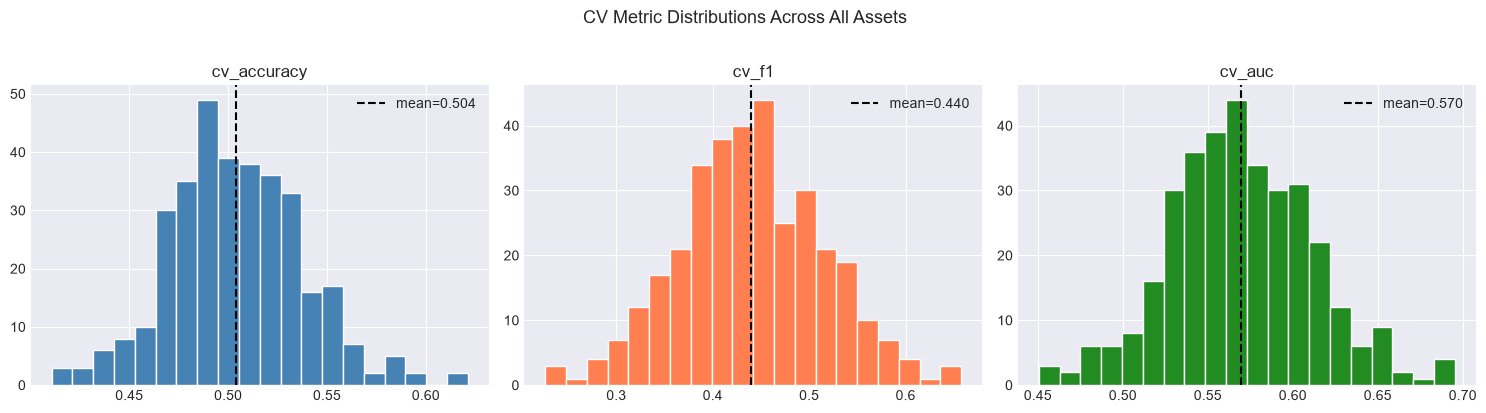

In [13]:
summary_df = pd.DataFrame(results).sort_values('cv_auc', ascending=False)
summary_csv = OUTPUT_DIR / 'training_summary.csv'
summary_df.to_csv(summary_csv, index=False)
print(f'Saved summary to {summary_csv}')

# Per asset-class averages
agg = summary_df.groupby('asset_class')[['cv_accuracy','cv_f1','cv_auc']].mean().round(4)
print('\n── Per-Class CV Averages ──')
display(agg)

# Top 10 models by AUC
print('\n── Top 10 Models by AUC ──')
display(summary_df[['asset_class','symbol','cv_accuracy','cv_f1','cv_auc','n_samples']].head(10))

# Distribution plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, colour in zip(axes, ['cv_accuracy','cv_f1','cv_auc'], ['steelblue','coral','forestgreen']):
    summary_df[col].hist(bins=20, ax=ax, color=colour, edgecolor='white')
    ax.axvline(summary_df[col].mean(), color='black', linestyle='--', label=f'mean={summary_df[col].mean():.3f}')
    ax.set_title(col)
    ax.legend()
plt.suptitle('CV Metric Distributions Across All Assets', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Feature Importance Plots

In [14]:
def plot_feature_importance(model, feat_names, title, save_path, top_n=20):
    imp = pd.Series(model.feature_importances_, index=feat_names)
    imp = imp.nlargest(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.3)))
    imp.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Importance (Gain)')
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.close()

# Plot top model per asset class
for asset_class in ASSET_CLASSES:
    ac_dir = MODEL_DIR / asset_class
    if not ac_dir.exists():
        continue
    # Find best AUC model for this class
    ac_rows = summary_df[summary_df.asset_class == asset_class]
    if ac_rows.empty:
        continue
    best_symbol = ac_rows.sort_values('cv_auc', ascending=False).iloc[0]['symbol']
    pkl_path = ac_dir / f'{best_symbol}_xgb.pkl'
    if not pkl_path.exists():
        continue
    with open(pkl_path, 'rb') as f:
        obj = pickle.load(f)
    save_img = FEAT_DIR / f'{asset_class}_{best_symbol}_importance.png'
    plot_feature_importance(
        obj['model'], obj['meta']['feature_names'],
        title=f'{asset_class} / {best_symbol} — Feature Importance',
        save_path=save_img,
    )
    log.info('Saved importance plot: %s', save_img.name)

print('Feature importance plots saved.')

Saved importance plot: Crypto_SOL_importance.png
Saved importance plot: ETFs_XLV_importance.png
Saved importance plot: Commodities_WTI_Crude_Oil_importance.png
Saved importance plot: Futures_NIFTY_50_Futures_importance.png
Saved importance plot: Stocks_NSmallcap_DOMS_importance.png


Feature importance plots saved.


## 7. Hyperparameter Tuning (Grid Search on Best Asset)

In [15]:
from sklearn.model_selection import GridSearchCV

# Use the globally best model's data for tuning
best_row = summary_df.sort_values('cv_auc', ascending=False).iloc[0]
best_ac, best_sym = best_row['asset_class'], best_row['symbol']
best_csv = TRAIN_DIR / best_ac / f'{best_sym}_features.csv'

X_tune, y_tune, feat_names_tune, _ = load_and_preprocess(best_csv, TARGET_COL, DROP_COLS)
print(f'Tuning on: {best_ac}/{best_sym}  ({len(y_tune)} rows)')

param_grid = {
    'max_depth'      : [3, 4, 5],
    'learning_rate'  : [0.03, 0.05, 0.10],
    'n_estimators'   : [200, 300],
    'min_child_weight': [1, 3],
}

base_xgb = xgb.XGBClassifier(
    subsample=0.8, colsample_bytree=0.8,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=class_balance(y_tune),
    eval_metric='logloss', verbosity=0,
    random_state=RANDOM_STATE, n_jobs=N_JOBS,
)

tscv_tune = TimeSeriesSplit(n_splits=3)
grid_search = GridSearchCV(
    base_xgb, param_grid, cv=tscv_tune,
    scoring='roc_auc', n_jobs=N_JOBS, verbose=1,
)
grid_search.fit(X_tune, y_tune)

print(f'\nBest params : {grid_search.best_params_}')
print(f'Best AUC    : {grid_search.best_score_:.4f}')

# Update XGB_PARAMS with best params
XGB_PARAMS_TUNED = {**XGB_PARAMS, **grid_search.best_params_}
print('\nTuned params ready for re-training.')

Tuning on: Stocks/NSmallcap_DOMS  (502 rows)
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best params : {'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 200}
Best AUC    : 0.7570

Tuned params ready for re-training.


## 8. Re-train with Tuned Params & Save Final Models

In [16]:
tuned_results = []

for asset_class, paths in INVENTORY.items():
    ac_model_dir = MODEL_DIR / asset_class
    ac_model_dir.mkdir(parents=True, exist_ok=True)

    for csv_path in tqdm(paths, desc=f'[Tuned] {asset_class}', leave=False):
        symbol = csv_path.stem.replace('_features', '')
        try:
            X, y, feat_names, _ = load_and_preprocess(csv_path, TARGET_COL, DROP_COLS)
        except Exception as e:
            continue
        if len(np.unique(y)) < 2 or len(y) < 50:
            continue

        params = {**XGB_PARAMS_TUNED, 'scale_pos_weight': class_balance(y)}
        fold_metrics = []
        for train_idx, val_idx in tscv.split(X):
            m = xgb.XGBClassifier(**params)
            m.fit(X[train_idx], y[train_idx], eval_set=[(X[val_idx], y[val_idx])], verbose=False)
            yp = m.predict(X[val_idx])
            yprob = m.predict_proba(X[val_idx])[:, 1]
            fold_metrics.append({
                'accuracy': accuracy_score(y[val_idx], yp),
                'f1': f1_score(y[val_idx], yp, zero_division=0),
                'auc': roc_auc_score(y[val_idx], yprob) if len(np.unique(y[val_idx])) > 1 else 0.5,
            })

        final = xgb.XGBClassifier(**params)
        final.fit(X, y, verbose=False)

        meta = {
            'symbol': symbol, 'asset_class': asset_class,
            'feature_names': feat_names,
            'trained_at': datetime.now().isoformat(),
            'n_samples': len(y), 'target': TARGET_COL,
            'tuned': True,
            'cv_accuracy': float(np.mean([m['accuracy'] for m in fold_metrics])),
            'cv_f1'      : float(np.mean([m['f1']       for m in fold_metrics])),
            'cv_auc'     : float(np.mean([m['auc']      for m in fold_metrics])),
        }
        pkl_path = ac_model_dir / f'{symbol}_xgb.pkl'
        with open(pkl_path, 'wb') as f:
            pickle.dump({'model': final, 'meta': meta}, f)
        tuned_results.append(meta)

tuned_df = pd.DataFrame(tuned_results).sort_values('cv_auc', ascending=False)
print(f'Re-trained {len(tuned_df)} models with tuned params.')
display(tuned_df.groupby('asset_class')[['cv_accuracy','cv_f1','cv_auc']].mean().round(4))

Re-trained 341 models with tuned params.


,cv_accuracy,cv_f1,cv_auc
asset_class,,,
Commodities,0.5165,0.5097,0.5593
Crypto,0.5225,0.4451,0.6081
ETFs,0.5113,0.4625,0.5744
Futures,0.4839,0.4431,0.5967
Stocks,0.5044,0.4346,0.5712


## 9. Summary Report

In [18]:
report_lines = [
    '=' * 60,
    'FinNexus XGBoost Training Report',
    f'Generated : {datetime.now().strftime("%Y-%m-%d %H:%M")}',
    f'Target    : {TARGET_COL}',
    f'CV Splits : {N_CV_SPLITS}',
    '=' * 60,
    '',
    f'Total models trained : {len(tuned_df)}',
    '',
]

for ac in ASSET_CLASSES:
    sub = tuned_df[tuned_df.asset_class == ac]
    if sub.empty:
        continue
    report_lines.append(f'[{ac}]  {len(sub)} assets')
    report_lines.append(f'  Avg Accuracy : {sub.cv_accuracy.mean():.4f}')
    report_lines.append(f'  Avg F1       : {sub.cv_f1.mean():.4f}')
    report_lines.append(f'  Avg AUC      : {sub.cv_auc.mean():.4f}')
    best = sub.sort_values('cv_auc', ascending=False).iloc[0]
    report_lines.append(f'  Best model   : {best.symbol}  AUC={best.cv_auc:.4f}')
    report_lines.append('')

report_lines += [
    '── Global Best (top 5 by AUC) ──',
    tuned_df[['asset_class','symbol','cv_auc','cv_f1','cv_accuracy']]
        .head(5).to_string(index=False),
    '',
    'Models saved to:', str(MODEL_DIR),
    '=' * 60,
]

report_text = '\n'.join(report_lines)
report_path = OUTPUT_DIR / 'xgb_training_report.txt'
report_path.write_text(report_text, encoding='utf-8')

print(report_text)

# Save final summary CSV
tuned_df.to_csv(OUTPUT_DIR / 'training_summary.csv', index=False)
print(f'Summary CSV saved: {OUTPUT_DIR / "training_summary.csv"}')

FinNexus XGBoost Training Report
Generated : 2026-06-25 17:48
Target    : target_7d
CV Splits : 5

Total models trained : 341

[Crypto]  10 assets
  Avg Accuracy : 0.5225
  Avg F1       : 0.4451
  Avg AUC      : 0.6081
  Best model   : SOL  AUC=0.6675

[ETFs]  15 assets
  Avg Accuracy : 0.5113
  Avg F1       : 0.4625
  Avg AUC      : 0.5744
  Best model   : XLV  AUC=0.6774

[Commodities]  13 assets
  Avg Accuracy : 0.5165
  Avg F1       : 0.5097
  Avg AUC      : 0.5593
  Best model   : WTI_Crude_Oil  AUC=0.6304

[Futures]  10 assets
  Avg Accuracy : 0.4839
  Avg F1       : 0.4431
  Avg AUC      : 0.5967
  Best model   : NIFTY_50_Options  AUC=0.7228

[Stocks]  293 assets
  Avg Accuracy : 0.5044
  Avg F1       : 0.4346
  Avg AUC      : 0.5712
  Best model   : NSmallcap_DOMS  AUC=0.7004

── Global Best (top 5 by AUC) ──
asset_class               symbol   cv_auc    cv_f1  cv_accuracy
    Futures     NIFTY_50_Options 0.722795 0.507446     0.473171
    Futures     NIFTY_50_Futures 0.722795 0